8. We will now perform cross-validation on a simulated data set.

(a) Generate a simulated data set as follows:</br>

`rng = np.random.default_rng(1)`  
`x = rng.normal(size=100)`  
`y = x - 2 * x**2 + rng.normal(size=100)`  

<p>In this data set, what is n and what is p? Write out the model</br>
used to generate the data in equation form.</br>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

In [2]:
rng = np.random.default_rng (1)
# 產生 100 筆 N(0,1) 的隨機自變數
x = rng.normal(size =100) 
# 根據非線性模型 y = x - 2x^2 + ε 產生 y，其中 ε ~ N(0,1) 根據非線性模型 + 隨機雜訊生成 y
y = x - 2 * x**2 + rng.normal(size =100)

n = number of observations (樣本數)</br>
x and y have 100 elements → n = 100</br>
</p>
p = number of predictors (自變數個數)</br>
the only predictor variable is x → p = 1</br>

(b) Create a scatterplot of X against Y . Comment on what you find.

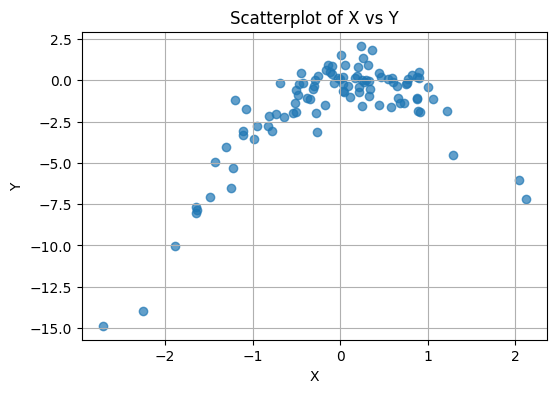

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# scatter plot
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.7)
plt.title("Scatterplot of X vs Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

當 x 值較小（接近 0 左右）時，y 會隨 x 增加而上升。</br>
當 x 到達大約 0.25 附近 時，y 達到最高點。 當 x 繼續增大或變成負值，y 會急劇下降。</br>
非線性（二次拋物線）關係</br>

LOOCV（Leave-One-Out Cross-Validation）：每次拿走一筆資料當驗證，其餘 n−1，n−1 筆用來訓練；重複 n次，把每次的測試誤差取平均作為模型的泛化誤差估計。
### (c) random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:  
  
i. $Y = \beta_0 + \beta_1X + \epsilon$

ii. $Y = \beta_0 + \beta_1X + \beta_2X^2 + \epsilon$

iii. $Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

iv. $Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \beta_4X^4 + \epsilon$  
  
###Note you may find it helpful to use the `data.frame()` function to create a single data set containing both X and Y .

In [4]:
# 建立 DataFrame
data = pd.DataFrame({'x': x, 'y': y})
data

,x,y
0,0.345584,-0.544554
1,0.821618,0.333950
2,0.330437,-0.013532
3,-1.303157,-4.030442
4,0.905356,0.484861
...,...,...
95,-2.250854,-14.001012
96,-0.138655,0.932532
97,0.033000,0.198928
98,-1.425349,-4.940183


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
import statsmodels.api as sm

def loocv_error(x, y, degree):
    n = len(y)
    errors = []
    for i in range(n):
        # leave-one-out
        x_train = np.delete(x, i)
        y_train = np.delete(y, i)
        
        # polynomial features
        X_train = np.vander(x_train, degree+1, increasing=True)
        X_test = np.vander([x[i]], degree+1, increasing=True)
        
        # fit model using least squares
        model = sm.OLS(y_train, X_train).fit()
        
        # predict left-out point
        y_pred = model.predict(X_test)[0]
        
        # squared error
        errors.append((y[i] - y_pred)**2)
    
    return np.mean(errors)

degrees = [1, 2, 3, 4]
cv_errors = []

for d in degrees:
    error = loocv_error(x, y, d)
    cv_errors.append(error)
    print(f"Degree {d} model LOOCV MSE = {error:.4f}")



Degree 1 model LOOCV MSE = 6.6330
Degree 2 model LOOCV MSE = 1.1229
Degree 3 model LOOCV MSE = 1.3018
Degree 4 model LOOCV MSE = 1.3324


Model 1 (Linear Model): 6.6330</br>
Model 2 (Quadratic Model): 1.1229</br>
Model 3 (Cubic Model): 1.3018</br>
Model 4 (Quartic Model): 1.3324</br>

(d) Repeat (c) using another random seed, and report your results.</br>
Are your results the same as what you got in (c)? Why?</br>

In [8]:
import numpy as np
import statsmodels.api as sm

# 改變 random seed
np.random.seed(42) 


# 計算不同多項式階數的 LOOCV 誤差
degrees = [1, 2, 3, 4]
for d in degrees:
    error = loocv_error(x, y, d)
    print(f"Degree {d} model LOOCV MSE = {error:.4f}")


Degree 1 model LOOCV MSE = 7.5606
Degree 2 model LOOCV MSE = 0.9840
Degree 3 model LOOCV MSE = 0.9682
Degree 4 model LOOCV MSE = 0.9660


| 隨機種子       | Degree=1 | Degree=2 | Degree=3 | Degree=4 | 最佳模型 |
| ---------- | -------- | -------- | -------- | -------- | ---- |
| Seed=1 (c) | 6.6330    | 1.1229 | 1.3018     |1.3324    | 2    |
| Seed=2 (d) | 7.5606    | 0.9840 | 0.9682     | 0.9660     | 4    |

使用不同的隨機種子運行時，會生成不同的數值，</br>
影響LOOCV（留一交叉驗證）誤差。由於數據集是隨機生成的，改變隨機種子會改變數據中的噪聲，可能會導致不同的LOOCV誤差值。</br>
整體趨勢（例如二次模型可能具有最低的誤差）可能保持相似，因為生成數據的基本過程並未改變。這說明了模型表現如何隨著不同隨機樣本略有變化。</br>


(e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.</br>
在 (c) 部分中，LOOCV 誤差最小的模型是二次模型
$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon
$$
二次關係式的結構，二次模型自然最能貼近資料的真實分佈，因此在 LOOCV 中會得到最低的誤差。：
$$
y = x - 2x^2 + \epsilon
$$
高次多項式模型：</br>
  過於複雜，可能引入不必要的彎曲與波動，甚至造成過度擬合，因此不一定能得出更低的 LOOCV 誤差。</br>
線性模型：</br>
  太過簡單，無法描述資料中明顯的曲線特性，所以 LOOCV 誤差反而會更大。</br>
二次模型的良好表現反映了資料的真正生成方式。它最能捕捉 $X$ 與 $Y$ 之間的實際關係，因此在 LOOCV 中得到最佳的結果。</br>


(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares.</br>
 Do these results agree with the conclusions drawn based on the cross-validation results?</br>

檢查每個模型中的回歸係數是否具有統計顯著性。
然後檢查這些統計顯著性的結果是否與交叉驗證（LOOCV）得到的誤差結果一致。

統計顯著性與交叉驗證結果一致：</br>
這些統計顯著性的結果與交叉驗證結果是相一致的。具體來說：</br>
二次模型最能擬合資料，並且 x, x^2</br>
  這兩個項對預測的貢獻是顯著的，這與交叉驗證結果一致，二次模型擁有最低的 LOOCV 誤差。</br>
高次模型（如三次和四次模型）儘管某些回歸係數顯示顯著性，但它們並未改善預測能力，反而增加了不必要的模型複雜性，導致預測誤差增大。</br>
過度擬合的問題：</br>
高次多項式模型（例如三次和四次模型）引入了無用的回歸項，儘管某些係數顯示顯著性，但它們未能改善模型的預測能力。這表明，在建模過程中，選擇合適的模型結構至關重要，過度擬合會導致模型複雜化，且不一定提升預測準確性。</br>